# ДЗ 3 метод к ближайших соседей  
датасет вина с огромным количеством числовых признаков:  
https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Сначала произведем первичый анализ данных  

In [2]:
import pandas as pd

df = pd.read_csv("WineQT.csv")

print(f" Shape: {df.shape}")
print("Information:  ")
print(df.info())
print("Детальное описание")
print(df.describe())


 Shape: (1143, 13)
Information:  
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None
Детальное описание
       fixed acidity  volati

как мы видим, что пропусков в датасете нет, поэтому создадим их искусственно  
в категории качество. И поделим датасет на две части исходя из того где знаем число и где его искусственно убрали

In [3]:
import numpy as np

featureToPredict = "alcohol"
featuresForPrediction = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'density', 'pH', 'sulphates']


df_temp = df.copy()

np.random.seed(42)
mask = np.random.random(len(df_temp)) < 0.2
df_temp.loc[mask, featureToPredict] = np.nan

df_known = df_temp.dropna(subset=[featureToPredict])
df_unknown = df_temp[df_temp[featureToPredict].isna()]


X_train = df_known[featuresForPrediction]
y_train = df_known[featureToPredict]
X_predict = df_unknown[featuresForPrediction]

После того как мы разделили наш датасет на части known и unknown части без пропусков и с ними и так же поделили часть known для обучения KNN  
Далее можно перейте к нормализации данных 

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_predict_scaled = scaler.transform(X_predict)

Будем искать оптимальное значения k для нашей модели

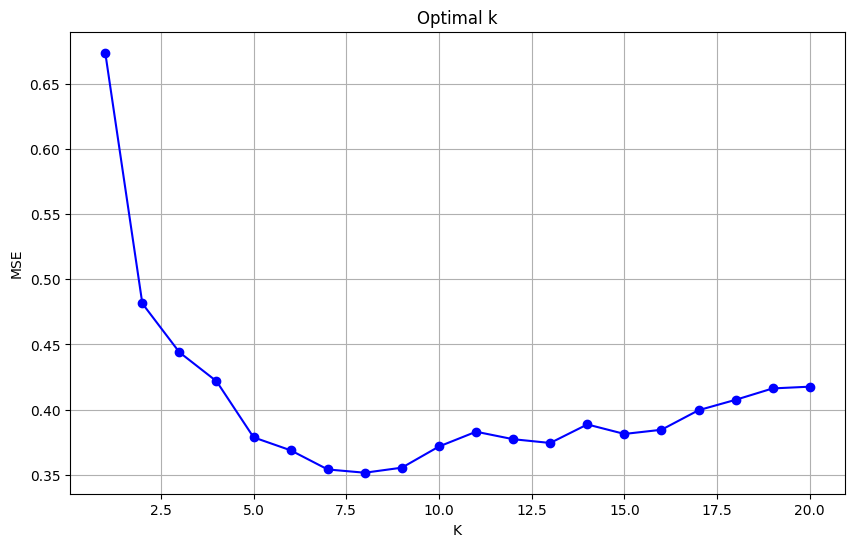

Optimal k: 8


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

mymetr = "cosine"

k_values = range(1, 21)
mse_scores = []

X_train_split, X_val, y_train_split, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state = 42)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, metric=mymetr)
    knn.fit(X_train_split, y_train_split)
    y_pred = knn.predict(X_val)
    mse_scores.append(mean_squared_error(y_val, y_pred))

plt.figure(figsize=(10,6))
plt.plot(k_values, mse_scores, 'bo-')
plt.xlabel('K')
plt.ylabel('MSE')
plt.title("Optimal k")
plt.grid(True)
plt.show()

opt = k_values[np.argmin(mse_scores)]
print(f"Optimal k: {opt}")

In [11]:
knn_final = KNeighborsRegressor(n_neighbors=opt, metric=mymetr)
knn_final.fit(X_train_scaled, y_train)
predicted_values = knn_final.predict(X_predict_scaled)

actual_values = df.loc[df_unknown.index, featureToPredict]
print(f"RMSE: {np.sqrt(mean_squared_error(actual_values, predicted_values)):.4f}")
print(f"R2 Score: {r2_score(actual_values, predicted_values):.4f}")

RMSE: 0.6652
R2 Score: 0.6512


В итоге при тесте различных метрик расхождения в предсказании оказались минимальными, но оптимальное значение k менялось